# Evalvaluate Predictions

In [1]:
import os
import polars as pl
import numpy as np
from deeptan.utils.metrics import MetricsDictMaker, format_ticks

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Computing metrics

In [2]:
path_home_deeptan = "/mnt/hdd2/homext/wuch/xn2p"
path_predictions = os.path.join(path_home_deeptan, "run", "predict")
path_raw_df = os.path.join(path_home_deeptan, "data", "raw_df")

### scMultiome

In [3]:
dataset = "sc_multiome_minmi0.35_top2000"
path_true = os.path.join(path_raw_df, "scMultiome", "Ath_scMultiome_WT_split_strata")

metricsmaker_scmul = MetricsDictMaker(os.path.join(path_predictions, dataset), path_true)
metricsmaker_scmul.run()

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not de

### snRNA-seq

In [4]:
dataset = "sc_rna_annotated_minmi0.0_top2000"
path_true = os.path.join(path_raw_df, "scRNA", "GSE226097_Annotated_split_strata")

metricsmaker_snrna = MetricsDictMaker(os.path.join(path_predictions, dataset), path_true)
metricsmaker_snrna.run()

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not de

## Plot

##### Choose a dataset to plot

In [5]:
_tmp_dataset = metricsmaker_scmul

fig_name = "fig.c2.scmul.recon.dist"

In [6]:
dim = "sample_metrics"
# dim = "feature_metrics"

met = ["mse", "mae", "jsd", "pcc"]
met_text = ["MSE", "MAE", "JSD", "PCC"]

x_lab = "multitask"
x_lab_text = "Multitask"

# y_labs = ["multitask_noguide", "focus_recon", "focus_label"]
# y_labs_text = ["Multitask (no SGG)", "Focus on reconstruction", "Focus on labelling"]
y_labs = ["focus_recon", "focus_label"]
y_labs_text = ["Focus on reconstruction", "Focus on labelling"]

In [7]:
_seed = 42
_dataset = {}
for _task in [x_lab]+y_labs:
    _dataset[_task] = {}
    _dataset[_task][dim] = {}
    for _met in met:
        _fname = _tmp_dataset.metrics_dict["summary_recon"].filter((pl.col("task")==_task) & (pl.col("metric")==_met) & (pl.col("seed_num")==_seed))["fname"].item()
        _dataset[_task][dim][_met] = _tmp_dataset.metrics_dict["metrics"]["recon"][_fname][dim][_met]

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


<Figure size 640x480 with 0 Axes>

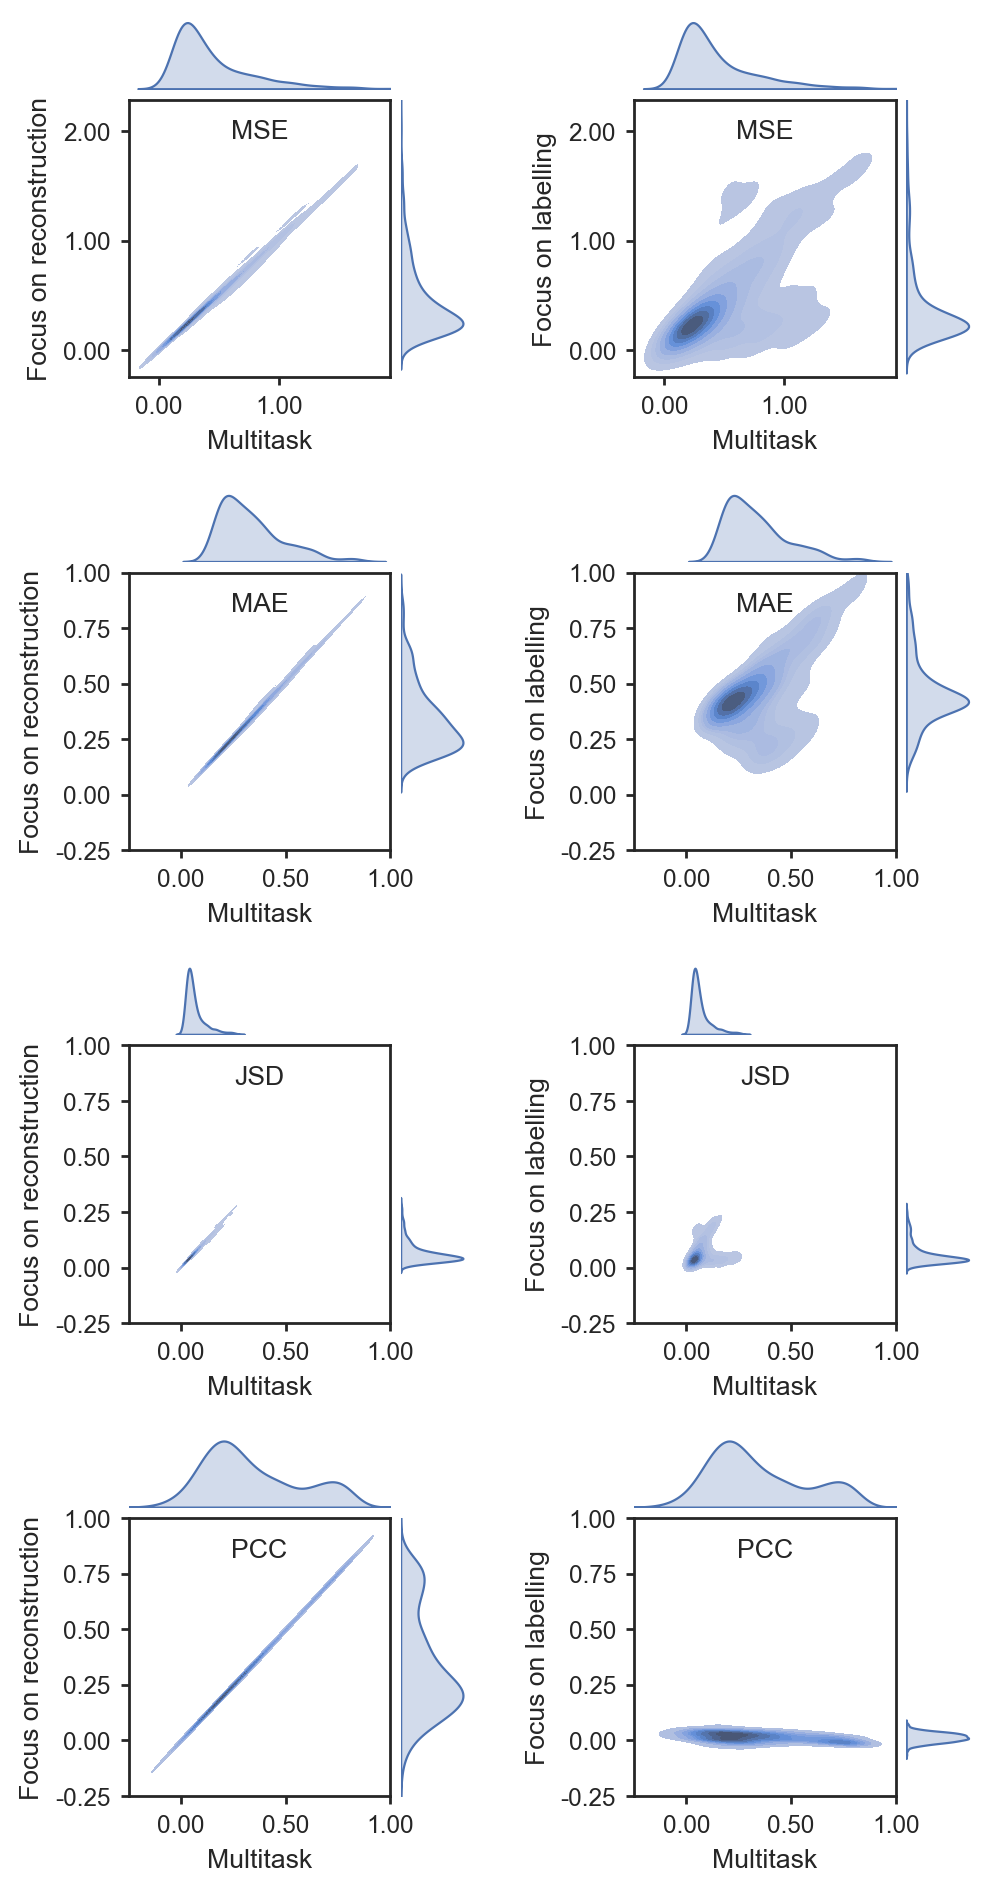

In [9]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
# a4_width_cm = 21
# cm_to_inches = 0.393701
# a4_width_inches = a4_width_cm * cm_to_inches
n_cols = len(y_labs)
n_rows = len(met)

fig_width = 2.6 * n_cols  # 调整图表的整体宽度以适应列数
fig_height = 2.4 * n_rows  # 调整图表的整体高度以适应行数

sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.0)  # 设置图表的上下文和字体大小

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=False,  # 不共享 x 轴
    sharey=False,  # 不共享 y 轴
)

if n_rows == 1:
    axes = axes.reshape(1, -1)

# 用于存储每行的 x 和 y 的最小值和最大值
row_limits = []

for i, _met in enumerate(met):
    row_x_min, row_x_max = float(-0.25), float(1.0)
    row_y_min, row_y_max = float(-0.25), float(1.0)

    for j, y_lab in enumerate(y_labs):
        ax = axes[i, j]
        x_data = _dataset[x_lab][dim][_met]["values"]
        y_data = _dataset[y_lab][dim][_met]["values"]

        sns.kdeplot(
            ax=ax,
            x=x_data,
            y=y_data,
            fill=True,
        )
        # 手动添加边缘直方图
        ax_histx = ax.inset_axes((0.0, 1.04, 1.0, 0.25), sharex=ax)
        ax_histy = ax.inset_axes((1.04, 0.0, 0.25, 1.0), sharey=ax)
        sns.kdeplot(x=_dataset[x_lab][dim][_met]["values"], ax=ax_histx, fill=True, legend=False)
        sns.kdeplot(y=_dataset[y_lab][dim][_met]["values"], ax=ax_histy, fill=True, legend=False)
        # 移除边缘分布图的刻度、标签和边框
        ax_histx.set_ylabel(None)
        ax_histy.set_xlabel(None)
        ax_histx.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax_histy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax_histx.spines.values():
            spine.set_visible(False)
        for spine in ax_histy.spines.values():
            spine.set_visible(False)
        # 禁用网格
        ax_histx.grid(False)
        ax_histy.grid(False)

        # 设置标题和标签
        ax.set_title(met_text[i], y=0.8)
        ax.set_xlabel(x_lab_text)
        ax.set_ylabel(y_labs_text[j])

        # 更新当前行的 x 和 y 的最小值和最大值
        row_x_min = row_x_min if np.isnan(min(x_data)) or np.isinf(min(x_data)) else min(row_x_min, min(x_data))
        row_x_max = row_x_max if np.isnan(max(x_data)) or np.isinf(max(x_data)) else max(row_x_max, max(x_data))
        row_y_min = row_y_min if np.isnan(min(y_data)) or np.isinf(min(y_data)) else min(row_y_min, min(y_data))
        row_y_max = row_y_max if np.isnan(max(y_data)) or np.isinf(max(y_data)) else max(row_y_max, max(y_data))

        # 设置刻度格式化器
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))

        # 缩短刻度棒的长度
        ax.tick_params(axis="both", which="major", length=3)  # 主刻度棒长度
        ax.tick_params(axis="both", which="minor", length=2)  # 次刻度棒长度

    # 保存当前行的最小值和最大值
    row_limits.append(((row_x_min, row_x_max), (row_y_min, row_y_max)))

    # ax = axes[i, j+1]
    # sns.barplot(x=[x_lab_text]+y_labs_text, y=_dataset[y_lab][dim][_met]["mean"])

# 统一设置每行的 x 和 y 轴范围
for i, (_met, (x_limits, y_limits)) in enumerate(zip(met, row_limits)):
    for j, y_lab in enumerate(y_labs):
        ax = axes[i, j]
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)

# fig.subplots_adjust(wspace=0.4, hspace=0.3)
fig.tight_layout()
fig.show()

# Save as PNG and PDF
fig.savefig(f".fig/{fig_name}.png", dpi=300)
fig.savefig(f".fig/{fig_name}.pdf")

### PaCMAP

In [10]:
_tmp_dataset = metricsmaker_scmul
_seed = 42

fig_name = "fig.c2.scmul.cell_emb"

In [11]:
x_lab = "multitask"
x_lab_text = "Multitask"

# y_labs = ["multitask_noguide", "focus_recon", "focus_label"]
# y_labs_text = ["Multitask (no SGG)", "Focus on reconstruction", "Focus on labelling"]
y_labs = ["focus_recon", "focus_label"]
y_labs_text = ["Focus on reconstruction", "Focus on labelling"]

_tasks = [x_lab] + y_labs
_tasks_text = [x_lab_text] + y_labs_text

#### Get cell embeddings for each task

In [12]:
cell_embs = {}
_fnames = []
for _task in _tasks:
    _fname = _tmp_dataset.ident.filter((pl.col("task") == _task) & (pl.col("seed_num") == _seed))["fname"].item()
    _fnames.append(_fname)
    cell_embs[_task] = _tmp_dataset.metrics_dict["prediction"][_fname]["g_embedding"]

#### Get predicted cell labels for each task

In [13]:
# 获取所有文件中唯一的细胞类型标签
celltypes_uniq = _tmp_dataset.metrics_dict["prediction"][_fnames[0]]["label_names"][1:]
celltypes_uniq = [i.replace("ct_", "") for i in celltypes_uniq]
print(celltypes_uniq)

ys_pred_numeric = {}
ys_pred_text = {}
for _fname in _fnames:
    _task = _tmp_dataset.ident.filter(pl.col("fname")==_fname)["task"].item()
    ys_pred_numeric[_task] = _tmp_dataset.metrics_dict["prediction"][_fname]["y"].argmax(axis=1)
    ys_pred_text[_task] = [celltypes_uniq[i] for i in ys_pred_numeric[_task]]

['Atrichoblast', 'Columella', 'Cortex', 'Dividing.cells', 'Endodermis', 'Epidermis', 'Initials', 'LRC', 'Phloem', 'QC', 'Stele', 'Suberin.endo', 'Trichoblast', 'XPP', 'Xylem', 'unknown']


#### Get true cell types

In [ ]:
print(_tmp_dataset.metrics_dict["true"].keys())
print(_tmp_dataset.metrics_dict["true"][f"seed_{_seed}_tst"].keys())
print(_tmp_dataset.metrics_dict["true"][f"seed_{_seed}_tst"]["X"].shape)
print(_tmp_dataset.metrics_dict["true"][f"seed_{_seed}_tst"]["y"])

In [15]:
y_true_text = _tmp_dataset.metrics_dict["true"][f"seed_{_seed}_tst"]["y_df_flatten"]["ct"].to_list()

#### Compute PaCMAP

In [16]:
import pacmap

In [17]:
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)

# # fit the data (The index of transformed data corresponds to the index of the original data)
# X_transformed = embedding.fit_transform(X, init="pca")

cell_embs_pacmap = {}
for _task in cell_embs.keys():
    cell_embs_pacmap[_task] = embedding.fit_transform(cell_embs[_task], init="pca")
    print(f"Task {_task}: {cell_embs_pacmap[_task].shape}")

Task multitask: (564, 2)
Task focus_recon: (564, 2)
Task focus_label: (564, 2)


#### Now we can plot

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

<Figure size 640x480 with 0 Axes>

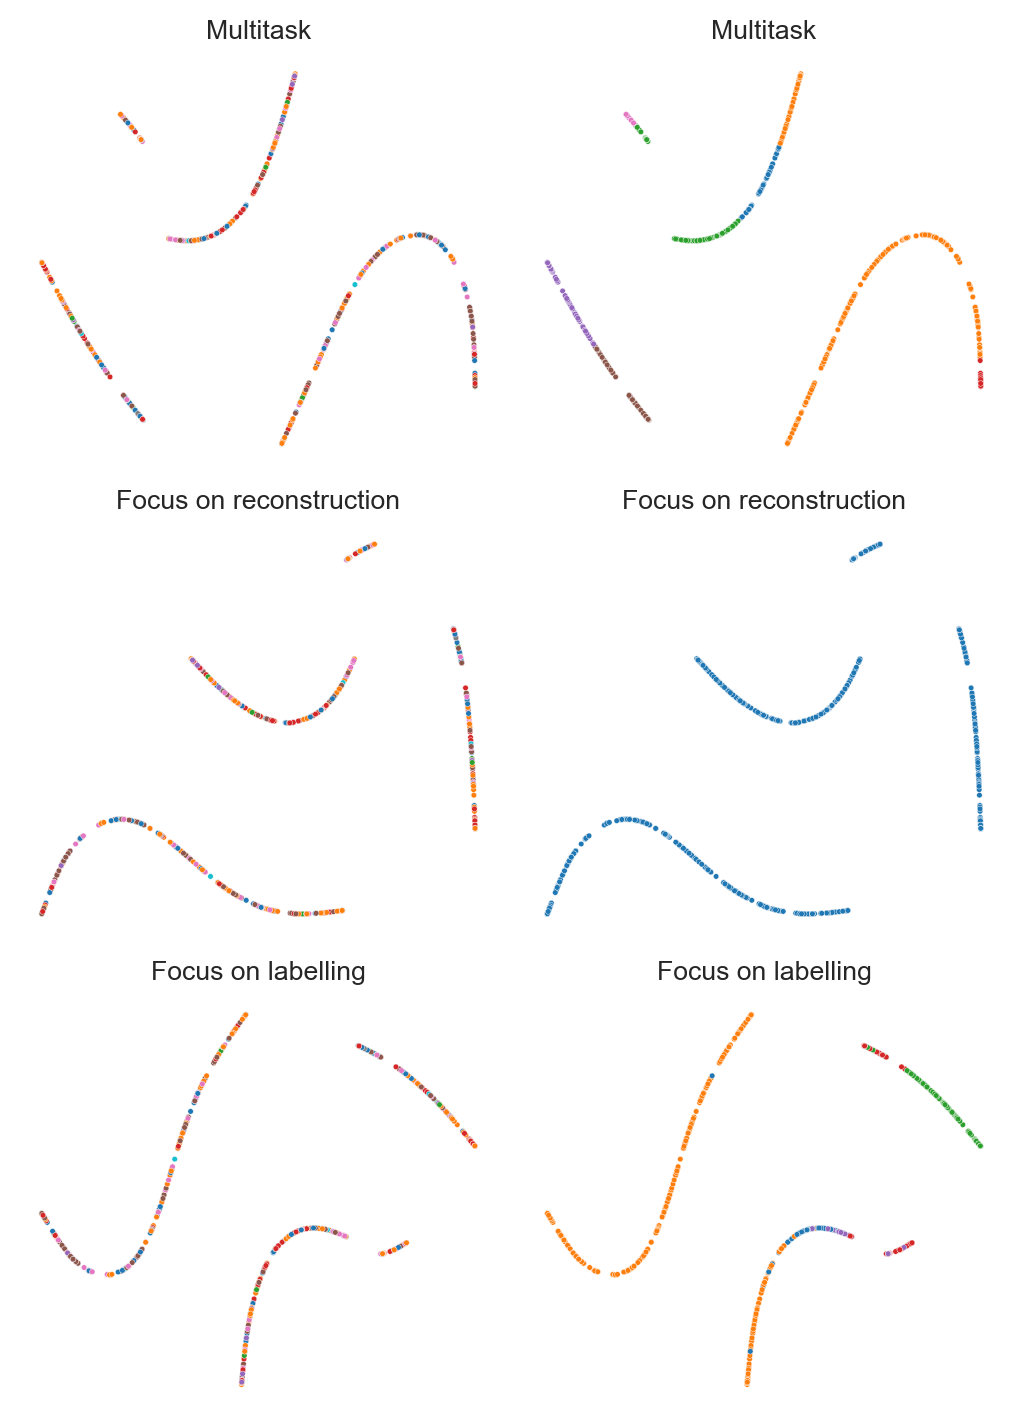

In [19]:
try:
    plt.clf()
except:
    pass

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
# a4_width_cm = 21
# cm_to_inches = 0.393701
# a4_width_inches = a4_width_cm * cm_to_inches
n_cols = 2
n_rows = len(cell_embs_pacmap)

fig_width = 2.6 * n_cols  # 调整图表的整体宽度以适应列数
fig_height = 2.4 * n_rows  # 调整图表的整体高度以适应行数

sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.0)  # 设置图表的上下文和字体大小

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=False,  # 不共享 x 轴
    sharey=False,  # 不共享 y 轴
)
if n_rows == 1:
    axes = axes.reshape(1, -1)

# sns.scatterplot(x=X_transformed[:, 0], y=X_transformed[:, 1], hue=y_true_text, palette="tab10", s=4, ax=ax[0])
# sns.scatterplot(x=X_transformed[:, 0], y=X_transformed[:, 1], hue=y_pred_text, palette="tab10", s=4, ax=ax[1])

for i, _task in enumerate(cell_embs_pacmap.keys()):
    ax = axes[i, 0]
    ax.set_title(_tasks_text[i])
    sns.scatterplot(x=cell_embs_pacmap[_task][:, 0], y=cell_embs_pacmap[_task][:, 1], hue=y_true_text, palette="tab10", s=4, ax=ax, legend=False)
    # 删除框线
    for spine in ax.spines.values():
        spine.set_visible(False)
    # 删除刻度棒和刻度数字
    ax.tick_params(axis='both', which='both', length=0)  # 隐藏刻度棒
    ax.set_xticks([])  # 清空 x 轴刻度
    ax.set_yticks([])  # 清空 y 轴刻度

    ax = axes[i, 1]
    ax.set_title(_tasks_text[i])
    sns.scatterplot(x=cell_embs_pacmap[_task][:, 0], y=cell_embs_pacmap[_task][:, 1], hue=ys_pred_text[_task], palette="tab10", s=4, ax=ax, legend=False)
    # 删除框线
    for spine in ax.spines.values():
        spine.set_visible(False)
    # 删除刻度棒和刻度数字
    ax.tick_params(axis='both', which='both', length=0)  # 隐藏刻度棒
    ax.set_xticks([])  # 清空 x 轴刻度
    ax.set_yticks([])  # 清空 y 轴刻度

fig.tight_layout()
fig.show()

# Save as PNG and PDF
# fig.savefig(f".fig/{fig_name}.png", dpi=300)
# fig.savefig(f".fig/{fig_name}.pdf")